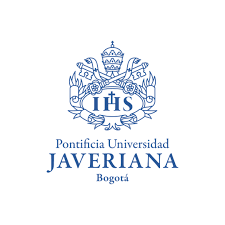
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Hernán Manuel Manrique Espíndola

Fecha de Inicio: 14-04-2026

Fecha entrega: 27-04-2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

# Levantamiento de variables de entorno pip


In [1]:
import os
import sys
sys.path.append('/usr/lib/python3/dist-packages/')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

os.environ["PYSPARK_PYTHON"]="/usr/bin/python3.9"
os.environ["PYSPARK_DRIVER_PYTHON"]="/usr/bin/python3.9"


### Levantamiento de sesión SPARK


In [2]:
configura = SparkConf()
configura.setAppName("Calidad_Agua_Manrique")
sparkManrique = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkManrique.sparkContext, sparkSession=sparkManrique)
sparkContextoS = sparkManrique.sparkContext.getOrCreate()
print("Sesion creada: ProcesamientoDatos04")
sparkManrique

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 00:58:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


**2.- Carga de Datos desde el HADOOP HDFS**



In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv
df00 = sparkManrique.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")
df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [4]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

In [5]:
df00.describe("STATION CODE").show()
df00.describe("LOCATIONS").show()
df00.describe("STATE").show()
df00.describe("TEMP").show()
df00.describe("DO").show()
df00.describe("pH").show()
df00.describe("CONDUCTIVITY").show()
df00.describe("BOD").show()
df00.describe("NITRATE_N_NITRITE_N").show()
df00.describe("FECAL_COLIFORM").show()
df00.describe("TOTAL_COLIFORM").show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+



+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+



+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|

## **Visualización de los DATOS NULOS**



In [6]:
#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones

In [7]:
#Se crea una vista para ser usada en las visualizaciones
df00.createOrReplaceTempView("df00_sql")

In [8]:
df01 = sparkManrique.sql('''Select * from df00_sql where TEMP is not null and

       DO is not null and

       pH is not null and

       CONDUCTIVITY is not null and

       BOD is not null and

       NITRATE_N_NITRITE_N is not null and

       FECAL_COLIFORM is not null''')

In [9]:
#Se verifica la Cantidad de Valores Nulos o Imposibles
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Tratamiento de datos**



In [10]:
#Tipos de datos antes del cambio 
print("Tipos de datos:" )
df00.dtypes

Tipos de datos:


[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]

In [11]:
##Se procede a cambiar los tipos de datos para una mejor visualización y análisis de los datos, se cambian a FloatType() para las columnas numéricas
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

In [12]:
#Se muestran los nuevos tipos de datos para verificar el cambio
print("Nuevos tipos de datos")
df00.dtypes

Nuevos tipos de datos


[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float'),
 ('TOTAL_COLIFORM', 'string')]

In [13]:
##Se elimina la columna TOTAL_COLIFORM 
df01 = df00.drop('TOTAL_COLIFORM')

#Se muestran las columnas tras eliminar la columna TOTAL_COLIFORM para verificar el cambio
print("Columnas después de eliminar la columna TOTAL_COLIFORM")
df01.columns

Columnas después de eliminar la columna TOTAL_COLIFORM


['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos


In [14]:
#Se crea una nueva vista para ser usada en las visualizaciones
df01.createOrReplaceTempView("df01_sql")

In [15]:
###Se crea una consulta por cada parámetro DO pH CONDUCTIVITY BOD NITRATE_N_NITRITE_N FECAL_COLIFORM 
do_parametro = sparkManrique.sql("Select DO from df01_sql")
ph_parametro = sparkManrique.sql("Select pH from df01_sql")
COND_parametro = sparkManrique.sql("Select CONDUCTIVITY from df01_sql")
BOD_parametro = sparkManrique.sql("Select BOD from df01_sql")
NN_parametro = sparkManrique.sql("Select NITRATE_N_NITRITE_N from df01_sql")
FC_parametro = sparkManrique.sql("Select FECAL_COLIFORM from df01_sql")

In [16]:
##Se hace una consulta para crear el vector de la tabla por cada parámetro 
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

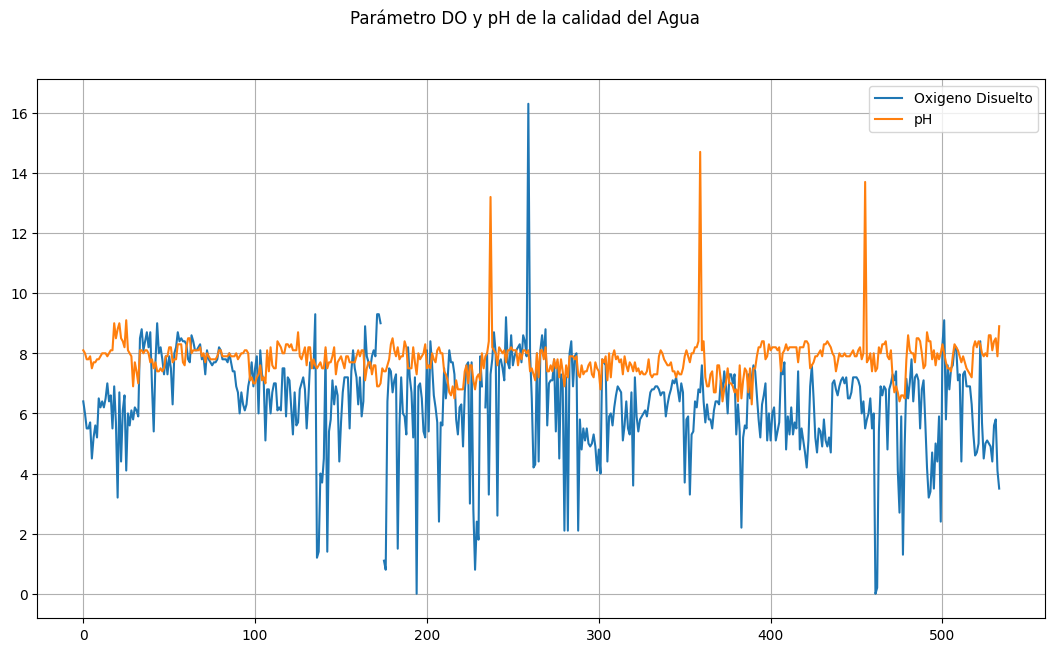

In [17]:
##Grafica los parámetros para conocer sus características: DO y PH
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w',edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

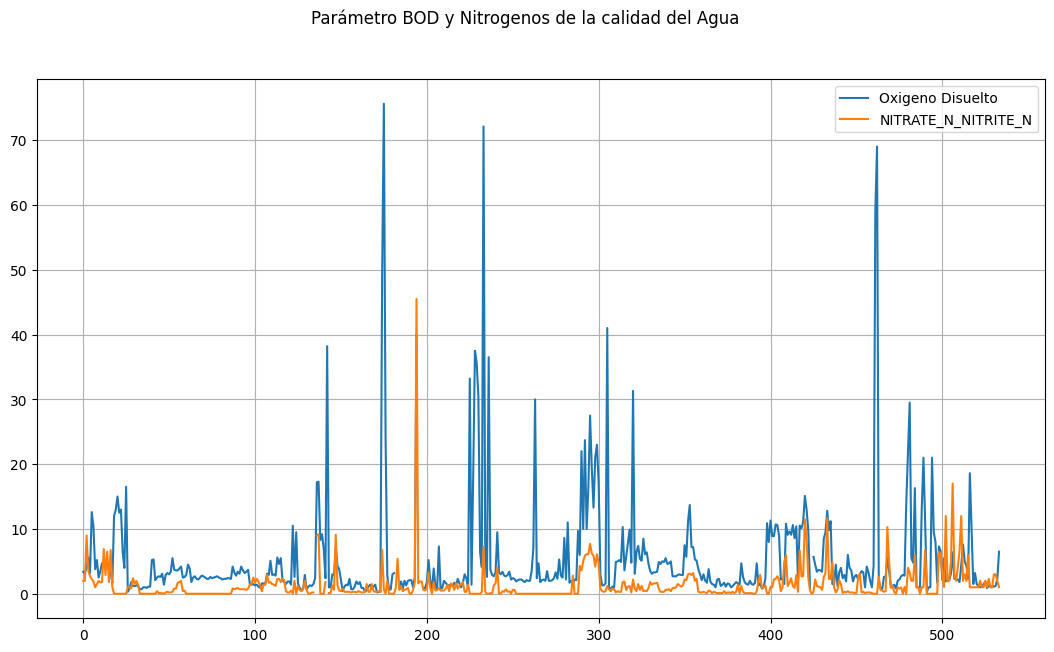

In [18]:
##Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

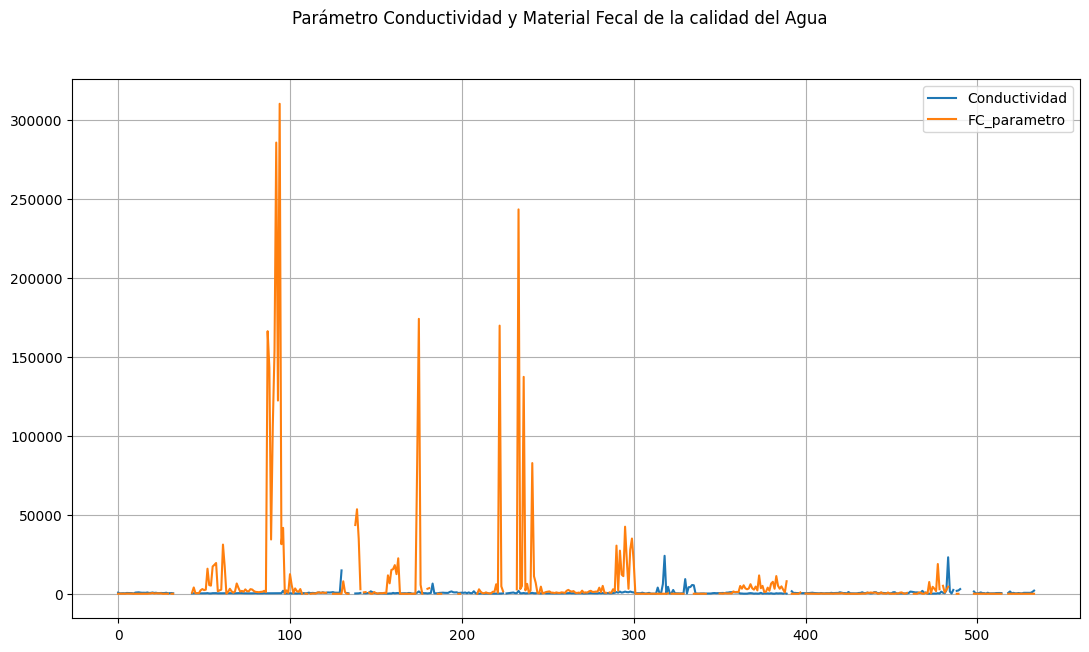

In [20]:
##Grafica Los parámetros para conocer sus características: FC y Conductividad
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

In [21]:
#Función definida por el usuario para definir el rango de calidad de agua según el pH
#Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).
 when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).
 when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).
 when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

In [22]:
### Función definida por el usuario para definir el rando de la calidad del agua según DO
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
 when((df01.DO>=5.1) & (df01.DO<6.0), 80).
 when((df01.DO>=4.1) & (df01.DO<5.0), 60).
 when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según COND

In [23]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
 when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
 when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
 when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD

In [24]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
 when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
 when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
 when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura

In [25]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
 when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
 when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
 when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

In [26]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
 when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
 when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
 when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

* **El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

In [27]:
#A continuación se hace una inspección en general del df02
df02.show(10)
#Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

In [28]:
###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)

df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [29]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))

df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [30]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
.when((df04.WQI>=25) & (df04.WQI<50),'Buena')
.when((df04.WQI>=50) & (df04.WQI<75),'Baja')
.when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
.otherwise('Inadecuada') )

df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

In [31]:
#Impresión de nombre de regiones sobre el mapa

colEstado = 'STATE'

valNomnbres = df05.select(colEstado).distinct().collect()

valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

In [32]:
import geopandas as gpd
rutaMapas = "/home/estudiante/Talleres_Arhe/WaterQuality/Indian_States.shp"

## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas 
print(type(gpd01))
gpd01.columns
#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

In [33]:
### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
               'Daman & Diu': 'Daman Diu', 
                'Jammu & Kashmir': 'Jammu Kashmir',
                'NCT of Delhi' : 'Delhi'
              })


gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

In [34]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [35]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

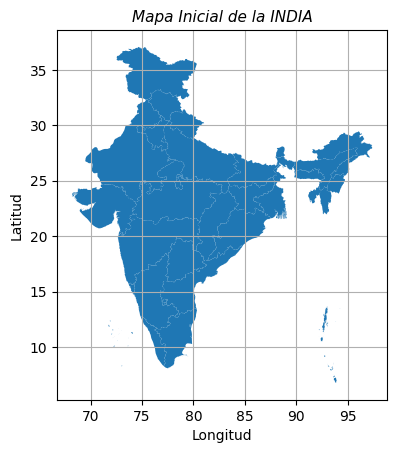

In [36]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [37]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


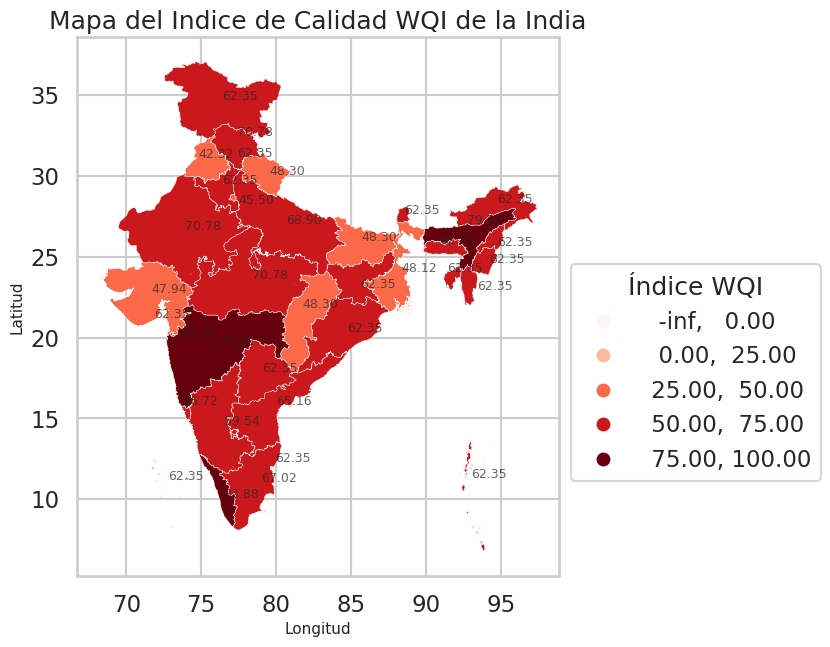

In [38]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

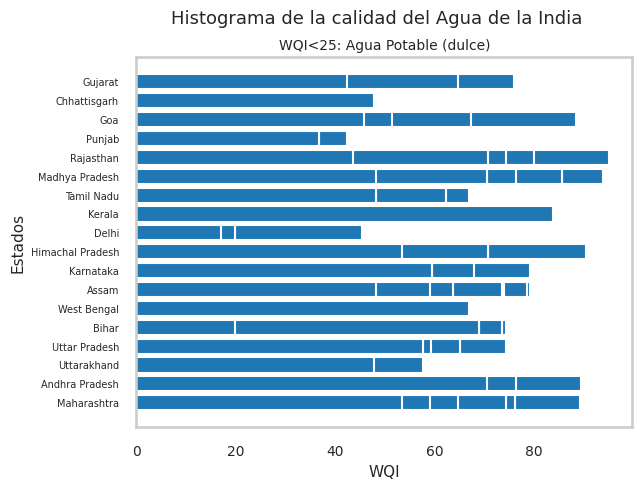

In [39]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkManrique.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkManrique.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [40]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [41]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [42]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [43]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [44]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

2026-04-27 01:00:08.293197: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 01:00:08.414712: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 01:00:09.957942: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [45]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 01:00:10.368189: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [46]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [47]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1418.2592 - mse: 1418.2592
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 142.3960 - mse: 142.3960
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 48.1045 - mse: 48.1045
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 29.1130 - mse: 29.1130
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 14.5329 - mse: 14.5329
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.7861 - mse: 7.7861
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.0278 - mse: 5.0278
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.3800 - mse: 3.3800
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.9518 - mse: 1.9518
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0769 - mse: 1.0769
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5318 - mse: 0.5318
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2598 - mse: 0.2598
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━

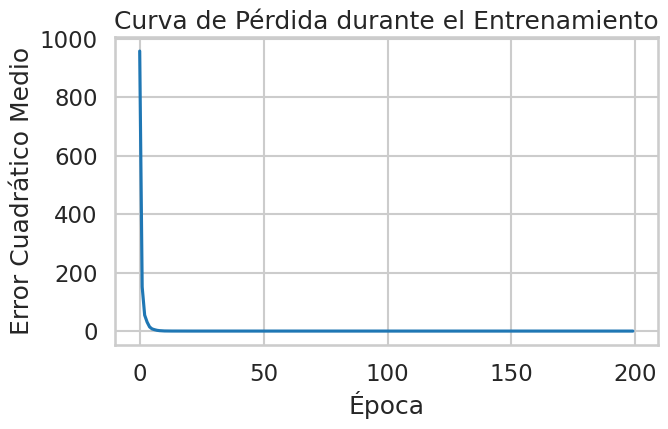

In [49]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Curva de Pérdida durante el Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Error Cuadrático Medio")
plt.show()

In [50]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


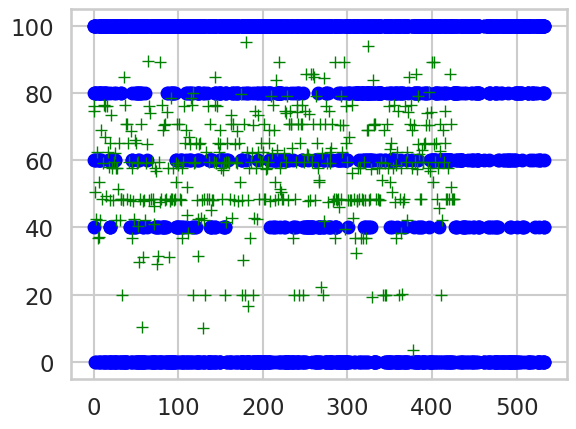

In [51]:
### Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()

### **Análisis del Índice de Calidad del Agua (WQI)**

A partir del cálculo del Índice de Calidad del Agua (WQI), se puede observar que los 
parámetros con mayor peso en la fórmula son el Oxígeno Disuelto (DO) y el Material 
Fecal (FECAL_COLIFORM), ambos con un peso de 0.281, lo cual representa el 56.2% del 
índice total. Esto es coherente con la literatura científica, ya que estos dos parámetros 
son los indicadores más directos de contaminación biológica y orgánica en cuerpos de agua.

El pH tiene un peso de 0.165, la Conductividad de 0.234, los Nitratos de 0.028 y la 
Demanda Bioquímica de Oxígeno (BOD) de apenas 0.009. Aunque el BOD tiene un peso bajo 
en este modelo, su impacto real en la calidad del agua puede ser significativo en zonas 
con alta actividad agrícola o industrial.

### **Análisis de los Rangos de Clasificación**

Los intervalos definidos para clasificar la calidad del agua son:
- **Excelente** (WQI = 0 - 25): Agua dulce, apta para consumo directo
- **Buena** (WQI = 25 - 50): Agua moderada, requiere tratamiento básico
- **Baja** (WQI = 50 - 75): Agua dura, requiere tratamiento avanzado
- **Muy Baja** (WQI = 75 - 100): Agua muy dura, uso muy restringido
- **Inadecuada** (WQI > 100): Agua residual, no apta para ningún uso sin tratamiento

Se observa que varios estados de la India presentan valores de WQI en los rangos de 
"Baja" e "Inadecuada", lo cual refleja problemáticas graves de contaminación hídrica, 
especialmente en regiones con alta densidad poblacional y actividad industrial.

### **Análisis del Modelo Keras**

El modelo de red neuronal implementado tiene la siguiente arquitectura:
- **Capa de entrada:** 6 neuronas (una por parámetro de calidad)
- **3 capas ocultas:** 350 neuronas cada una, función de activación ReLU
- **Capa de salida:** 1 neurona con activación lineal (predicción continua de WQI)
- **Optimizador:** Adam (learning rate = 0.001)
- **Función de pérdida:** Error Cuadrático Medio (MSE)
- **Épocas:** 200 | **Batch size:** 81

La elección de la función de activación **ReLU** en las capas ocultas es adecuada para 
este tipo de problema de regresión, ya que evita el problema del gradiente desvaneciente 
y permite que el modelo aprenda relaciones no lineales entre los parámetros de calidad 
del agua y el WQI.

La capa de salida usa activación **lineal**, lo cual es correcto porque el WQI es una 
variable continua y no se requiere transformación no lineal en la salida.

### **Análisis de la Curva de Pérdida**

La gráfica de pérdida (loss) durante el entrenamiento permite evaluar si el modelo 
converge correctamente. Si la curva desciende de manera sostenida y se estabiliza hacia 
las épocas finales, indica que el modelo aprendió correctamente los patrones en los datos. 
Si la curva se estabiliza demasiado rápido o presenta oscilaciones, podría indicar 
necesidad de ajustar el learning rate o el batch size.

Con 200 épocas y un batch size de 81, el modelo tiene suficientes iteraciones para 
ajustarse a los datos de entrenamiento. Sin embargo, al no contar con un conjunto de 
validación separado durante el entrenamiento, no es posible detectar overfitting 
directamente desde la curva de pérdida.

### **Análisis de la División de Datos**

Se utilizó una división 80/20 para entrenamiento y prueba respectivamente, con 
`random_state=1` para garantizar reproducibilidad. Esta proporción es estándar en 
aprendizaje automático y permite entrenar el modelo con suficientes datos mientras 
se reserva una porción representativa para evaluación.

Es importante destacar que el dataset de calidad de agua de la India contiene datos 
de múltiples estaciones a lo largo del tiempo, por lo que una división aleatoria podría 
mezclar datos de la misma estación en entrenamiento y prueba, lo cual podría inflar 
artificialmente las métricas de rendimiento.

### **Limitaciones del Análisis**

- El WQI calculado se basa únicamente en **7 parámetros**, cuando en la práctica se 
  pueden considerar más de 20 indicadores para una evaluación completa.
- Los pesos utilizados en el WQI provienen de una referencia bibliográfica específica 
  y pueden no ser representativos para todas las regiones de la India.
- El modelo no incluye la variable temporal (año de medición), lo cual podría mejorar 
  significativamente las predicciones al capturar tendencias históricas.

### **Conclusiones**

**1. Sobre la calidad del agua en la India:**
El análisis de los datos de los ríos de la India revela una situación preocupante en 
materia de calidad hídrica. A través del cálculo del WQI, se identificó que una 
proporción significativa de las estaciones de medición presenta índices en los rangos 
"Baja", "Muy Baja" e "Inadecuada", lo que indica niveles elevados de contaminación 
orgánica, bacteriológica y química en los cuerpos de agua analizados.

**2. Sobre el modelo de predicción:**
El modelo de red neuronal con Keras demostró ser una herramienta viable para la 
predicción del WQI a partir de parámetros fisicoquímicos y bacteriológicos. La 
arquitectura implementada, con tres capas densas de 350 neuronas y activación ReLU, 
logró capturar las relaciones no lineales entre las variables de entrada y el índice 
de calidad del agua.

**3. Sobre el procesamiento con PySpark:**
El uso de PySpark para el preprocesamiento y transformación de los datos demostró ser 
eficiente para el manejo del volumen de datos disponible. Las transformaciones de tipo 
de datos, la eliminación de valores nulos y la creación de nuevas columnas derivadas 
se realizaron de manera distribuida, lo que sienta las bases para escalar este análisis 
a datasets de mayor volumen.

**4. Sobre la visualización geoespacial:**
La integración entre PySpark, GeoPandas y Matplotlib permitió generar una visualización 
geoespacial del WQI sobre el mapa de la India. Este tipo de representación facilita la 
identificación de regiones críticas y apoya la toma de decisiones en materia de política 
ambiental y gestión del recurso hídrico.

**5. Sobre los parámetros más influyentes:**
El análisis de los pesos del WQI confirma que el Oxígeno Disuelto (DO) y el Material 
Fecal (FECAL_COLIFORM) son los factores más determinantes en la calidad del agua. 
Esto sugiere que las intervenciones prioritarias deberían enfocarse en reducir la 
contaminación bacteriológica y mejorar la oxigenación de los cuerpos de agua.

### **Observaciones**

- **Sobre los datos nulos:** El dataset no presentó valores nulos en las columnas 
  analizadas, lo cual facilita el proceso de modelado. Sin embargo, en un escenario 
  real con datos en tiempo real, el manejo de valores faltantes sería un paso crítico 
  que requeriría estrategias más robustas como imputación por KNN o interpolación temporal.

- **Sobre la escalabilidad:** Aunque el dataset utilizado es de tamaño moderado, la 
  arquitectura implementada con PySpark permite escalar el procesamiento a millones de 
  registros sin cambios significativos en el código. Esto es una ventaja importante en 
  contextos de monitoreo ambiental continuo.

- **Sobre el modelo Keras:** El modelo actual no incluye técnicas de regularización 
  como Dropout o BatchNormalization. En futuras iteraciones, sería recomendable 
  incorporarlas para mejorar la capacidad de generalización del modelo y reducir el 
  riesgo de sobreajuste (overfitting).

- **Sobre la metodología WQI:** Los rangos y pesos utilizados para el cálculo del WQI 
  están basados en una referencia específica para la India. Para aplicar este mismo 
  modelo en otros contextos geográficos, sería necesario recalibrar los parámetros 
  según las normativas locales (por ejemplo, normas OMS o estándares nacionales).

- **Sobre la representación del mapa:** La fusión entre los datos de Spark y GeoPandas 
  requirió una conversión a Pandas (`toPandas()`), lo que implica traer todos los datos 
  al nodo driver. En datasets masivos, esta operación podría generar cuellos de botella 
  de memoria y debería manejarse con precaución.